In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
# ============================================================
# AUTISM PREDICTION USING MACHINE LEARNING
# ============================================================
# We import all the tools (libraries) we need

import pandas as pd                          # For reading and handling data
import numpy as np                           # For numerical operations
import matplotlib.pyplot as plt              # For plotting graphs
import seaborn as sns                        # For better-looking graphs

from sklearn.model_selection import train_test_split   # To split data
from sklearn.ensemble import RandomForestClassifier    # Our ML model
from sklearn.preprocessing import LabelEncoder         # To convert text to numbers
from sklearn.metrics import (                          # To measure performance
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [7]:
import zipfile

zip_path = r"C:\Users\91890\OneDrive\Desktop\Autism_Prediction_Disorder\Autism.csv.zip"
extract_path = r"C:\Users\91890\OneDrive\Desktop\Autism_Prediction_Disorder\data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted successfully")

Extracted successfully


In [11]:
import os

path = r"C:\Users\91890\OneDrive\Desktop\Autism_Prediction_Disorder\data"

print(os.listdir(path))

['Autism_Data.arff']


In [13]:
file_path = r"C:\Users\91890\OneDrive\Desktop\Autism_Prediction_Disorder\data\Autism_Data.arff"

with open(file_path, "r", encoding="utf-8") as f:
    for i in range(20):
        print(f.readline())

A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD



1,1,1,1,0,0,1,1,0,0,26,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO

1,1,0,1,0,0,0,1,0,1,24,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO

1,1,0,1,1,0,1,1,1,1,27,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES

1,1,0,1,0,0,1,1,0,1,35,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO

1,0,0,0,0,0,0,1,0,0,40,f,?,no,no,Egypt,no,2,'18 and more',?,NO

1,1,1,1,1,0,1,1,1,1,36,m,Others,yes,no,'United States',no,9,'18 and more',Self,YES

0,1,0,0,0,0,0,1,0,0,17,f,Black,no,no,'United States',no,2,'18 and more',Self,NO

1,1,1,1,0,0,0,0,1,0,64,m,White-European,no,no,'New Zealand',no,5,'18 and more',Parent,NO

1,1,0,0,1,0,0,1,1,1,29,m,White-European,no,no,'United States',no,6,'18 and more',Self,NO

1,1,1,1,0,1,1,1,1,0,17,m,Asian,yes,yes,Bahamas,no,8,'18 and more

In [16]:
# ============================================================
# STEP 1: LOAD THE DATA
# ============================================================
# pd.read_csv() reads the CSV file into a "DataFrame" (like an Excel table in Python)

df = pd.read_csv(r"C:\Users\91890\OneDrive\Desktop\Autism_Prediction_Disorder\data\Autism_Data.arff")

print("Shape of dataset:", df.shape)
# Shape tells us: (number of rows, number of columns)
# More rows = more patients, more columns = more features

print("\nFirst 5 rows of data:")
print(df.head())
# head() shows the first 5 rows so we can see what the data looks like

print("\nColumn names:")
print(df.columns.tolist())
# Tells us what information is stored in this dataset

print("\nMissing values in each column:")
print(df.isnull().sum())
# isnull() checks if any cell is empty/missing
# We need to fix missing values before training

print("\nHow many YES vs NO cases:")
print(df['Class/ASD'].value_counts())
# This tells us if our data is balanced
# e.g., 300 YES and 300 NO is balanced; 500 YES and 50 NO is imbalanced

Shape of dataset: (704, 21)

First 5 rows of data:
   A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0         1         1         1         1         0         0         1   
1         1         1         0         1         0         0         0   
2         1         1         0         1         1         0         1   
3         1         1         0         1         0         0         1   
4         1         0         0         0         0         0         0   

   A8_Score  A9_Score  A10_Score  ... gender       ethnicity jundice austim  \
0         1         0          0  ...      f  White-European      no     no   
1         1         0          1  ...      m          Latino      no    yes   
2         1         1          1  ...      m          Latino     yes    yes   
3         1         0          1  ...      f  White-European      no    yes   
4         1         0          0  ...      f               ?      no     no   

     contry_of_res used

In [17]:
# ============================================================
# STEP 2: PREPROCESS THE DATA
# ============================================================

# Make a copy of data so we don't accidentally change the original
data = df.copy()

# --- Handle missing values ---
# Some columns might have '?' or empty cells
# We replace '?' with the most common value in that column
data.replace('?', np.nan, inplace=True)

for col in data.columns:
    if data[col].dtype == 'object':                    # If column has text values
        data[col].fillna(data[col].mode()[0], inplace=True)   # Fill with most common value
    else:                                              # If column has numbers
        data[col].fillna(data[col].median(), inplace=True)    # Fill with middle value

print("Missing values after cleaning:")
print(data.isnull().sum())

# --- Convert text columns to numbers (Label Encoding) ---
# ML algorithms need numbers, not words like 'Male', 'Female', 'YES', 'NO'
# LabelEncoder converts: 'Female' -> 0, 'Male' -> 1 (alphabetical order)

le = LabelEncoder()

# Find all columns that have text (object dtype)
text_columns = data.select_dtypes(include='object').columns.tolist()
print("\nText columns to encode:", text_columns)

for col in text_columns:
    data[col] = le.fit_transform(data[col])
    # fit_transform() learns the unique values and converts them to numbers

print("\nData after encoding (first 5 rows):")
print(data.head())

Missing values after cleaning:
A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

Text columns to encode: ['age', 'gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before', 'age_desc', 'relation', 'Class/ASD']

Data after encoding (first 5 rows):
   A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0         1         1         1         1         0         0         1   
1         1         1         0         1         0         0         0   
2         1         1         0         1         1         0         1   
3         1         1       

C:\Users\91890\AppData\Local\Temp\ipykernel_27360\3304959393.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)    # Fill with middle value
C:\Users\91890\AppData\Local\Temp\ipykernel_27360\3304959393.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

Columns after dropping leaky features:
['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before', 'relation', 'Class/ASD']
Features shape (X): (704, 18)
Target shape (y): (704,)
Training set size: 563
Testing set size: 141
Model training complete!

Model Accuracy: 98.58%

Classification Report:
              precision    recall  f1-score   support

   No Autism       1.00      0.98      0.99       105
      Autism       0.95      1.00      0.97        36

    accuracy                           0.99       141
   macro avg       0.97      0.99      0.98       141
weighted avg       0.99      0.99      0.99       141

Cross-validation scores: [0.97163121 0.94326241 0.94326241 0.9787234  0.94285714]
Mean CV Accuracy: 95.59%
Standard Deviation: 1.59%


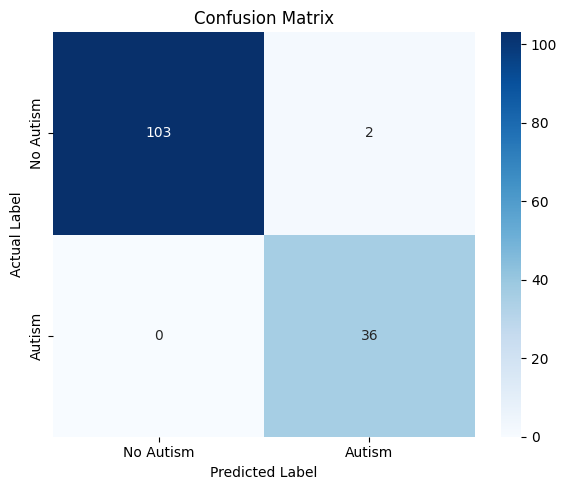

C:\Users\91890\AppData\Local\Temp\ipykernel_27360\626930809.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


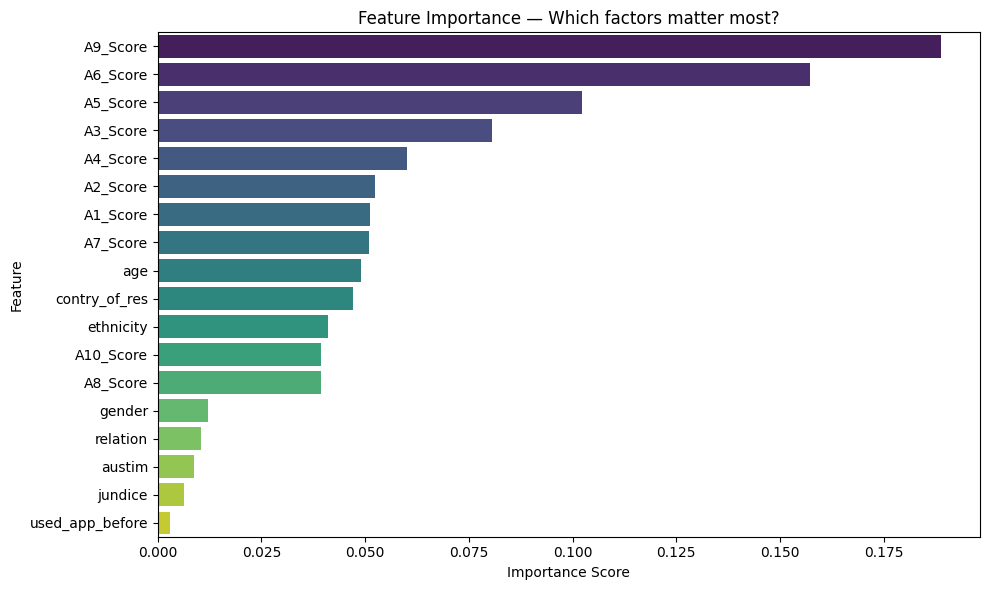

In [24]:



# ============================================================
# *** DROP LEAKY COLUMNS — ADD THIS RIGHT HERE ***
# After cleaning and encoding, but BEFORE defining X and y
# ============================================================

columns_to_drop = ['result', 'age_desc']
columns_to_drop = [col for col in columns_to_drop if col in data.columns]
data = data.drop(columns=columns_to_drop, axis=1)

print("Columns after dropping leaky features:")
print(data.columns.tolist())


# ============================================================
# STEP 3: SEPARATE FEATURES (X) AND TARGET (y)
# ============================================================

X = data.drop('Class/ASD', axis=1)
y = data['Class/ASD']

print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)


# ============================================================
# STEP 4: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])


# ============================================================
# STEP 5: TRAIN THE MODEL
# ============================================================

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Model training complete!")


# ============================================================
# STEP 6: EVALUATE — ACCURACY & REPORT
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Autism', 'Autism']))


# ============================================================
# *** CROSS VALIDATION — ADD THIS RIGHT HERE ***
# After the basic accuracy, still inside evaluation section
# ============================================================

cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_scores.std() * 100:.2f}%")


# ============================================================
# STEP 7: VISUALIZE — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Autism', 'Autism'],
            yticklabels=['No Autism', 'Autism'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()


# ============================================================
# STEP 8: VISUALIZE — FEATURE IMPORTANCE
# ============================================================

importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance — Which factors matter most?')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [23]:
# ============================================================
# STEP 9: PREDICT FOR A NEW PATIENT
# ============================================================

# This is a dictionary representing one new patient's answers
# Fill in the values as if a real patient filled the screening form

new_patient = {
    'A1_Score': 1,        # Answer to question 1  (0 = No, 1 = Yes)
    'A2_Score': 1,        # Answer to question 2
    'A3_Score': 1,        # Answer to question 3
    'A4_Score': 1,        # Answer to question 4
    'A5_Score': 1,        # Answer to question 5
    'A6_Score': 1,        # Answer to question 6
    'A7_Score': 1,        # Answer to question 7
    'A8_Score': 1,        # Answer to question 8
    'A9_Score': 1,        # Answer to question 9
    'A10_Score': 1,       # Answer to question 10
    'age': 25,            # Age of the patient
    'gender': 1,          # 0 = Female, 1 = Male
    'ethnicity': 0,       # Encoded ethnicity (0 is the first category alphabetically)
    'jundice': 0,         # Was patient born with jaundice? 0 = No, 1 = Yes
    'austim': 0,          # Family member with autism? 0 = No, 1 = Yes
    'contry_of_res': 0,   # Encoded country of residence
    'used_app_before': 0, # Used autism screening app before? 0 = No, 1 = Yes
    'relation': 0         # Who filled the form? (0 = Self, etc.)
}

# Convert the dictionary into a DataFrame
# The model expects input in the same format it was trained on
new_patient_df = pd.DataFrame([new_patient])

# Make sure columns are in the same order as training data
new_patient_df = new_patient_df[X.columns]

# ============================================================
# PREDICT
# ============================================================

# predict() gives the final decision: 0 = No Autism, 1 = Autism
prediction = model.predict(new_patient_df)

# predict_proba() gives the probability/confidence for each class
# [probability of No Autism,  probability of Autism]
prediction_proba = model.predict_proba(new_patient_df)

print("\n" + "="*50)
print("       NEW PATIENT PREDICTION RESULT")
print("="*50)

if prediction[0] == 1:
    print("Prediction  : AUTISM DETECTED")
else:
    print("Prediction  : NO AUTISM DETECTED")

print(f"Confidence  : {max(prediction_proba[0]) * 100:.2f}%")
print(f"Probability of No Autism : {prediction_proba[0][0] * 100:.2f}%")
print(f"Probability of Autism    : {prediction_proba[0][1] * 100:.2f}%")

print("\nNOTE: This is a screening tool only.")
print("Always consult a medical professional for diagnosis.")
print("="*50)


       NEW PATIENT PREDICTION RESULT
Prediction  : AUTISM DETECTED
Confidence  : 84.00%
Probability of No Autism : 16.00%
Probability of Autism    : 84.00%

NOTE: This is a screening tool only.
Always consult a medical professional for diagnosis.


In [25]:
# ============================================================
# STEP 10: SAVE THE TRAINED MODEL TO A FILE
# ============================================================
import pickle

# pickle saves the trained model as a .pkl file
# So Flask can load it without retraining every time

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Also save the column names so Flask knows the correct order
with open('columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("Model saved as model.pkl")
print("Columns saved as columns.pkl")

Model saved as model.pkl
Columns saved as columns.pkl
